In [1]:
import torch
import matplotlib.pyplot as plt

from transformers import AutoVideoProcessor, AutoModel, AutoImageProcessor
from transformers import pipeline

import os
import torch
import numpy as np

from torchcodec.decoders import VideoDecoder
from IPython.display import Video
import pandas as pd

import torchvision
import gc

In [2]:
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-small', use_fast=True)
model = AutoModel.from_pretrained('facebook/dinov2-small')


In [3]:
device='cpu'

In [4]:
dataset_path = '/data/scratch/hmz574/scratch-aid/videos/training_test_videos/'
output_path = '/data/scratch/hmz574/scratch-aid/videos/training_test_videos_clips/'
file_list = os.listdir(dataset_path)

In [5]:
!mkdir /data/scratch/hmz574/scratch-aid/videos/training_test_videos_clips/

mkdir: cannot create directory ‘/data/scratch/hmz574/scratch-aid/videos/training_test_videos_clips/’: File exists


In [6]:
train_list = ['V'+ str(x + 1) + '.mp4' for x in range (32)]
train_list

['V1.mp4',
 'V2.mp4',
 'V3.mp4',
 'V4.mp4',
 'V5.mp4',
 'V6.mp4',
 'V7.mp4',
 'V8.mp4',
 'V9.mp4',
 'V10.mp4',
 'V11.mp4',
 'V12.mp4',
 'V13.mp4',
 'V14.mp4',
 'V15.mp4',
 'V16.mp4',
 'V17.mp4',
 'V18.mp4',
 'V19.mp4',
 'V20.mp4',
 'V21.mp4',
 'V22.mp4',
 'V23.mp4',
 'V24.mp4',
 'V25.mp4',
 'V26.mp4',
 'V27.mp4',
 'V28.mp4',
 'V29.mp4',
 'V30.mp4',
 'V31.mp4',
 'V32.mp4']

In [5]:
frame_rate = 30.0
offset = int(frame_rate * 0.1) # seconds
duration = int(frame_rate * 2) #seconds
video_name = 'V7'

In [6]:
print(dataset_path + video_name + '.mp4')
decoder = VideoDecoder(dataset_path + video_name + '.mp4', device='cpu')

/data/scratch/hmz574/scratch-aid/videos/training_test_videos/V7.mp4


In [7]:
decoder.metadata

VideoStreamMetadata:
  duration_seconds_from_header: 1200.032161
  begin_stream_seconds_from_header: 0.066016
  bit_rate: 373724.0
  codec: h264
  stream_index: 0
  begin_stream_seconds_from_content: 0.066016
  end_stream_seconds_from_content: 1200.098112
  width: 720
  height: 720
  num_frames_from_header: 36001
  num_frames_from_content: 36001
  average_fps_from_header: 30.0
  pixel_aspect_ratio: 1
  duration_seconds: 1200.032096
  begin_stream_seconds: 0.066016
  end_stream_seconds: 1200.098112
  num_frames: 36001
  average_fps: 30.000030932505993

In [8]:
decoder = VideoDecoder(dataset_path + video_name + '.mp4')

In [9]:
annotations = pd.read_csv('Video_annotation_V1-V40.tsv', sep='\t', names = ['start','end','video'])

In [10]:
#v1 = VideoDecoder(dataset_path + train_list[0])
annotations = annotations[annotations['video'] == video_name]
annotations

,start,end,video
191,125,315,V7
192,341,486,V7
193,667,1260,V7
194,1620,1690,V7
195,2060,2104,V7
196,2123,2139,V7
197,2422,2546,V7
198,3908,4106,V7
199,5946,6199,V7
200,6483,6620,V7


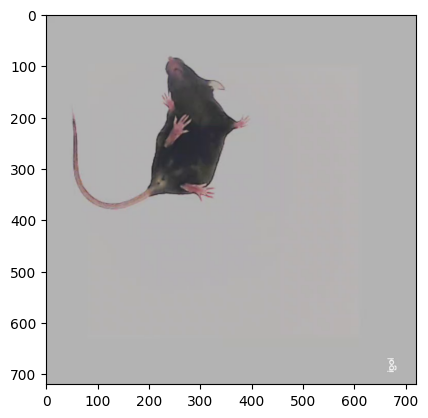

In [48]:
plt.imshow(decoder[0].swapaxes(0,2))

In [11]:
processor(images = decoder[0])['pixel_values'][0].min()

tensor(-1.4930)

In [24]:
embeddings = []
i = 0
for start in annotations['start']:
    print(i)
    i+=1
    scratch_index = (start + offset, start + offset + duration)
    nonscratch_index = (start - offset - duration, start - offset)
    scratch = decoder[scratch_index[0]:scratch_index[1]]
    nonscratch = decoder[nonscratch_index[0]:nonscratch_index[1]]
    with torch.no_grad():
        inputs = processor(images = scratch, return_tensors='pt').to(model.device)
        outputs = model(**inputs)
        last_hidden_state = outputs['last_hidden_state']
        scratch_cls_token = last_hidden_state[:,0]
    with torch.no_grad():
        inputs = processor(images = nonscratch, return_tensors='pt').to(model.device)
        outputs = model(**inputs)
        last_hidden_state = outputs['last_hidden_state']
        nonscratch_cls_token = last_hidden_state[:,0]
    embeddings.append([scratch_cls_token, nonscratch_cls_token])


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46


In [25]:
embeddings[0][0].mean(0).shape

torch.Size([384])

In [26]:
pooled_embeddings = []
for embed in embeddings:
    pooled_embeddings.append([embed[0].mean(0),embed[1].mean(0)])

In [27]:
np.save(video_name+'_embeds', np.array(embeddings))

In [28]:
np.array(embeddings).shape

(47, 2, 60, 384)

In [29]:
embedding_files = [np.load(x) for x in os.listdir() if '.npy' in x]
embeddings = np.concatenate(embedding_files, axis=0)

In [30]:
e = [x[0] for x in embeddings]
e.extend([x[1] for x in embeddings])
l = [1 for x in embeddings] # 1 == scratch
l.extend([0 for x in embeddings])

In [31]:
batch = [str(x) for x in range(len(embeddings))]
batch.extend(batch)
batch

['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '78',
 '79',
 '80',
 '81',
 '82',
 '83',
 '84',
 '85',
 '86',
 '87',
 '88',
 '89',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '97',
 '98',
 '99',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '110',
 '111',
 '112',
 '113',
 '114',
 '115',
 '116',
 '117',
 '118',
 '119',
 '120',
 '121',
 '122',
 '123',
 '124',
 '125',
 '126',
 '127',
 '128',
 '129',
 '130',
 '131',
 '132',
 '133',
 '134',
 '135',
 '136',
 '137',
 '138'

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    torch.Tensor(np.array(e)), torch.tensor(l), test_size=0.25, random_state=42)

In [33]:
Y_train

tensor([0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
        0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
        0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1,
        1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
        1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
        0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
        0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
        0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
        1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1])

In [40]:
from transformers import DistilBertConfig, DistilBertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
dim = np.array(e).shape[2]
configuration = DistilBertConfig(dim=dim,n_heads = 2,num_labels=2, n_layers=3)

model = DistilBertForSequenceClassification(configuration).to('cpu')

In [41]:
batch_size = 100
n_iters = 25000
num_epochs = n_iters / (len(X_train) / batch_size)
num_epochs = int(num_epochs)

# Pytorch train and test sets
train = TensorDataset(X_train, Y_train)
test = TensorDataset(X_test,Y_test)

# data loader
train_loader = DataLoader(train, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test, batch_size = batch_size, shuffle = True)

In [42]:
error = torch.nn.CrossEntropyLoss()
# SGD Optimizer
learning_rate = 0.005
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [43]:
seq_dim = 60  
loss_list = []
iteration_list = []
accuracy_list = []
count = 0

In [44]:
for epoch in range(num_epochs):
    for i, (train, targets) in enumerate(train_loader):

            
        # Clear gradients
        optimizer.zero_grad()
        model.train()
        
        # Forward propagation
        outputs = model(inputs_embeds = train.to(device))
        
        # Calculate softmax and ross entropy loss
        loss = error(outputs.logits, targets.to(device))
        
        # Calculating gradients
        loss.backward()
        
        # Update parameters
        optimizer.step()
        
        count += 1
        
        if count % 10 == 0:
            # Calculate Accuracy         
            correct = 0
            total = 0
            # Iterate through test dataset
            with torch.no_grad():
                for (test, test_targets) in test_loader:
                    model.eval()
                    # Forward propagation
                    outputs = model(inputs_embeds = test.to(device)).logits.argmax(dim=1)
                    
                    total += len(outputs)
                    correct += (outputs == test_targets.to(device)).sum()
                
                # store loss and iteration
                accuracy = correct*100/total
                loss_list.append(loss.data)
                iteration_list.append(count)
                accuracy_list.append(accuracy)
                
                # Print Loss
                print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))

Iteration: 10  Loss: 0.6832940578460693  Accuracy: 61.45833206176758 %
Iteration: 20  Loss: 0.6939782500267029  Accuracy: 57.29166793823242 %
Iteration: 30  Loss: 0.6827769875526428  Accuracy: 61.45833206176758 %
Iteration: 40  Loss: 0.6767175197601318  Accuracy: 62.5 %
Iteration: 50  Loss: 0.6801748871803284  Accuracy: 62.5 %
Iteration: 60  Loss: 0.6723278760910034  Accuracy: 63.54166793823242 %
Iteration: 70  Loss: 0.6602540016174316  Accuracy: 69.79166412353516 %
Iteration: 80  Loss: 0.6680824160575867  Accuracy: 63.54166793823242 %
Iteration: 90  Loss: 0.6696649789810181  Accuracy: 76.04166412353516 %
Iteration: 100  Loss: 0.6474840641021729  Accuracy: 72.91666412353516 %
Iteration: 110  Loss: 0.640504777431488  Accuracy: 67.70833587646484 %
Iteration: 120  Loss: 0.644682765007019  Accuracy: 72.91666412353516 %
Iteration: 130  Loss: 0.6395524740219116  Accuracy: 77.08333587646484 %
Iteration: 140  Loss: 0.6338003277778625  Accuracy: 77.08333587646484 %
Iteration: 150  Loss: 0.64072

KeyboardInterrupt: 

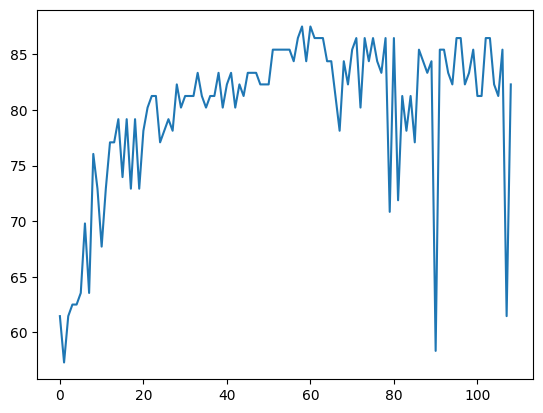

In [45]:
plt.plot(accuracy_list)

In [62]:
torch.save(model, 'scratch aid 2layer_model.pt')

In [13]:
ev = torch.load('scratch aid 2layer_model.pt', weights_only=False).eval()

In [64]:
ev = model.eval()

In [65]:
file_list = os.listdir('/data/scratch/hmz574/scratch-aid/videos/split')
file_list

['output_video033.mp4',
 'output_video193.mp4',
 'output_video596.mp4',
 'output_video1125.mp4',
 'output_video979.mp4',
 'output_video800.mp4',
 'output_video203.mp4',
 'output_video1039.mp4',
 'output_video915.mp4',
 'output_video460.mp4',
 'output_video151.mp4',
 'output_video1132.mp4',
 'output_video1003.mp4',
 'output_video672.mp4',
 'output_video470.mp4',
 'output_video133.mp4',
 'output_video666.mp4',
 'output_video807.mp4',
 'output_video145.mp4',
 'output_video248.mp4',
 'output_video705.mp4',
 'output_video354.mp4',
 'output_video1045.mp4',
 'output_video1015.mp4',
 'output_video045.mp4',
 'output_video578.mp4',
 'output_video719.mp4',
 'output_video504.mp4',
 'output_video909.mp4',
 'output_video617.mp4',
 'output_video442.mp4',
 'output_video780.mp4',
 'output_video522.mp4',
 'output_video293.mp4',
 'output_video637.mp4',
 'output_video907.mp4',
 'output_video1169.mp4',
 'output_video452.mp4',
 'output_video930.mp4',
 'output_video1035.mp4',
 'output_video075.mp4',
 'output

In [66]:
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-small', use_fast=True)
model = AutoModel.from_pretrained('facebook/dinov2-small')


In [86]:
segments = []

In [ ]:
for file_name in file_list:
    path = '/data/scratch/hmz574/scratch-aid/videos/split/' + file_name
    decoder = VideoDecoder(path)
    with torch.no_grad():
        inputs = processor(images = decoder[0:-1], return_tensors='pt').to(model.device)
        outputs = model(**inputs)
        last_hidden_state = outputs['last_hidden_state']
        cls_token = last_hidden_state[:,0]
    outputs = ev(inputs_embeds = cls_token[None]).logits
    print(file_name, outputs)
    segments.append([file_name, outputs])
    

output_video033.mp4 tensor([[ 2.6111, -2.8727]], grad_fn=<AddmmBackward0>)
output_video193.mp4 tensor([[ 2.7932, -3.0639]], grad_fn=<AddmmBackward0>)
output_video596.mp4 tensor([[ 4.3858, -4.6810]], grad_fn=<AddmmBackward0>)
output_video1125.mp4 tensor([[ 4.3550, -4.8603]], grad_fn=<AddmmBackward0>)
output_video979.mp4 tensor([[ 3.9598, -4.3543]], grad_fn=<AddmmBackward0>)
output_video800.mp4 tensor([[ 3.5532, -4.0215]], grad_fn=<AddmmBackward0>)
output_video203.mp4 tensor([[ 2.6873, -2.9330]], grad_fn=<AddmmBackward0>)
output_video1039.mp4 tensor([[ 3.0965, -3.2733]], grad_fn=<AddmmBackward0>)
output_video915.mp4 tensor([[ 3.8975, -4.3509]], grad_fn=<AddmmBackward0>)
output_video460.mp4 tensor([[ 3.8881, -4.3592]], grad_fn=<AddmmBackward0>)
output_video151.mp4 tensor([[ 4.4622, -4.9633]], grad_fn=<AddmmBackward0>)
output_video1132.mp4 tensor([[ 4.9705, -5.5825]], grad_fn=<AddmmBackward0>)
output_video1003.mp4 tensor([[-0.1356, -0.1008]], grad_fn=<AddmmBackward0>)
output_video672.mp4 t

In [14]:
file_list = os.listdir('mouse vids/split2')
file_list

['output_video033.mp4',
 'output_video151.mp4',
 'output_video133.mp4',
 'output_video145.mp4',
 'output_video045.mp4',
 'output_video075.mp4',
 'output_video070.mp4',
 'output_video121.mp4',
 'output_video183.mp4',
 'output_video147.mp4',
 'output_video109.mp4',
 'output_video155.mp4',
 'output_video010.mp4',
 'output_video164.mp4',
 'output_video120.mp4',
 'output_video134.mp4',
 'output_video161.mp4',
 'output_video098.mp4',
 'output_video079.mp4',
 'output_video000.mp4',
 'output_video073.mp4',
 'output_video039.mp4',
 'output_video163.mp4',
 'output_video066.mp4',
 'output_video173.mp4',
 'output_video068.mp4',
 'output_video012.mp4',
 'output_video127.mp4',
 'output_video144.mp4',
 'output_video143.mp4',
 'output_video105.mp4',
 'output_video089.mp4',
 'output_video084.mp4',
 'output_video078.mp4',
 'output_video003.mp4',
 'output_video180.mp4',
 'output_video167.mp4',
 'output_video159.mp4',
 'output_video091.mp4',
 'output_video026.mp4',
 'output_video031.mp4',
 'output_video10

In [15]:
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-small', use_fast=True)
model = AutoModel.from_pretrained('facebook/dinov2-small')


In [16]:
segments = []

In [ ]:
for file_name in file_list:
    path = 'mouse vids/split2/' + file_name
    decoder = VideoDecoder(path)
    with torch.no_grad():
        inputs = processor(images = decoder[0:-1], return_tensors='pt').to(model.device)
        outputs = model(**inputs)
        last_hidden_state = outputs['last_hidden_state']
        cls_token = last_hidden_state[:,0]
    outputs = ev(inputs_embeds = cls_token[None]).logits
    print(file_name, outputs)
    segments.append([file_name, outputs])
    

output_video033.mp4 tensor([[ 0.4917, -0.5485]], grad_fn=<AddmmBackward0>)
output_video151.mp4 tensor([[ 1.0950, -1.1863]], grad_fn=<AddmmBackward0>)
output_video133.mp4 tensor([[ 0.9158, -0.9781]], grad_fn=<AddmmBackward0>)
output_video145.mp4 tensor([[-0.7726,  0.9823]], grad_fn=<AddmmBackward0>)
output_video045.mp4 tensor([[-1.1038,  1.3467]], grad_fn=<AddmmBackward0>)
output_video075.mp4 tensor([[ 1.4401, -1.4674]], grad_fn=<AddmmBackward0>)
output_video070.mp4 tensor([[ 1.2288, -1.2720]], grad_fn=<AddmmBackward0>)
output_video121.mp4 tensor([[ 1.0527, -1.0731]], grad_fn=<AddmmBackward0>)
output_video183.mp4 tensor([[ 1.1554, -1.1880]], grad_fn=<AddmmBackward0>)
output_video147.mp4 tensor([[-0.5770,  0.7646]], grad_fn=<AddmmBackward0>)
output_video109.mp4 tensor([[0.0192, 0.0049]], grad_fn=<AddmmBackward0>)
output_video155.mp4 tensor([[ 1.0722, -1.1315]], grad_fn=<AddmmBackward0>)
output_video010.mp4 tensor([[ 0.8577, -0.8726]], grad_fn=<AddmmBackward0>)
output_video164.mp4 tensor(